## Background

Nesse Colab vamos criar um modelo híbrido, ilustrado na imagem abaixo, de QML para classificar as imagens do dataset MNIST.

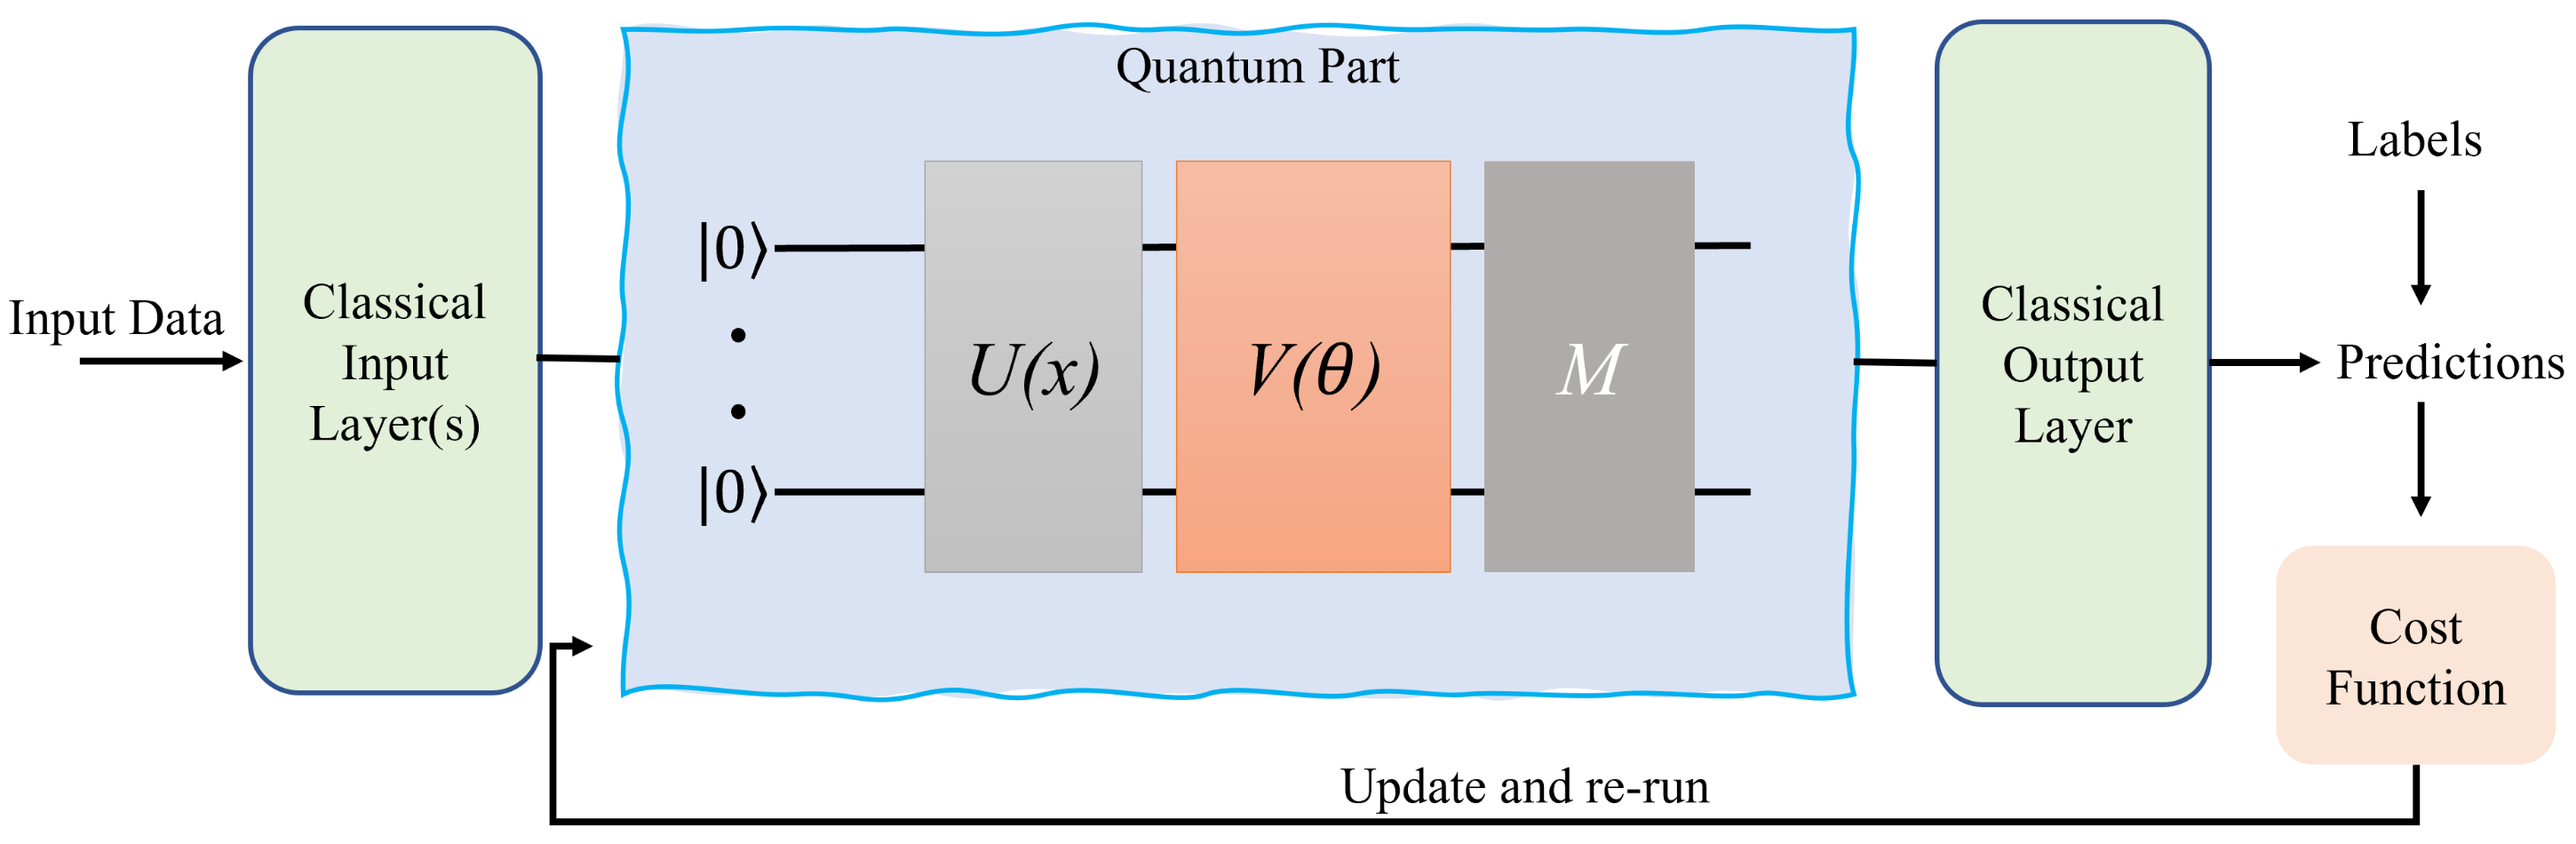

Como forma de optimizar o tempo de treinamento, o dataset foi limitado a duas classes.

A implementação seguirá as seguintes etapas:

1 - Instalação das bibliotecas necessárias.

2 - Definição da camada quântica.

3 - Definição do modelo híbrido.

4 - Loop de treinamento.

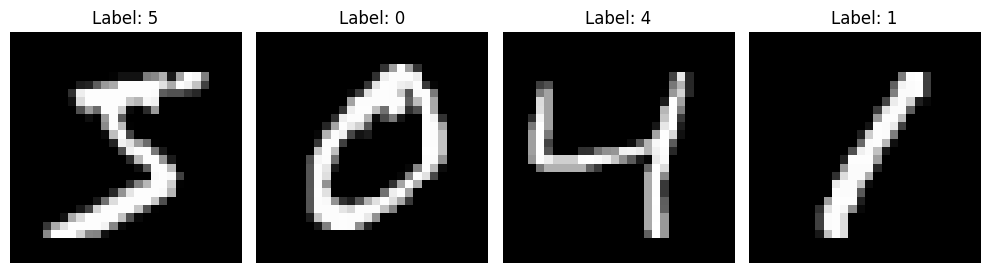

## 1 - Instalando dependências

In [ ]:
!pip install pennylane torch torchvision
!pip install scikit-learn matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 749.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 38.6 MB/s eta 0:00:00


In [ ]:
import pennylane as qml
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report
from torchvision import datasets, transforms

## 2 - Definição da camada quântica

A camada quântica é a responsável por extrair as características do conjunto de dados, e o seu resultado será usado como entrada para a camada clássica realizar a classificação final.

In [ ]:
n_qubits = 4 # define quantidade de qubits que o circuito terá.

n_layers = 2 # número de vezes que uma sequência específica de portas quânticas são aplicadas aos seus qubits.

dev = qml.device("default.qubit", wires=n_qubits)

In [ ]:
@qml.qnode(dev, interface="torch")

def qnode(inputs, weights):
  qml.AngleEmbedding(inputs, wires=range(n_qubits)) # Encoding dos dados clássicos

  qml.BasicEntanglerLayers(weights, wires=range(n_qubits)) # Porta parametrizada para extração de características

  return [qml.expval(qml.PauliZ(wires = i)) for i in range(n_qubits)] # Medição final

weight_shapes = {"weights": (n_layers, n_qubits)}
qlayer = qml.qnn.TorchLayer(qnode, weight_shapes) # Empacotamento para Pytorch

## 3 - Definição do modelo híbrido

No modelo híbrido juntamos a camada clássica de redução de dimensionalidade, a camada quântica de extração de características e a camada clássica final de classificação.

In [ ]:
class HybridModel(nn.Module):
  def __init__(self):
    super(HybridModel, self).__init__()

    # Redução de dimensionalidade (28x28 = 784 -> 4)
    self.fc1 = nn.Linear(28*28, 64)
    self.relu = nn.ReLU()
    self.fc2 = nn.Linear(64, n_qubits)

    # camada quântica
    self.qlayer = qlayer

    # classificação final
    self.fc3 = nn.Linear(n_qubits, 2)

  def forward(self, x):
    x = x.view(-1, 28*28)
    x = self.relu(self.fc1(x))
    x = self.fc2(x)

    # escala a saída clássica para ângulos entre -pi e pi (para o AngleEmbedding)
    x = torch.tanh(x) * np.pi

    x = self.qlayer(x)
    x = self.fc3(x)
    return x

## 4 - Treinamento

In [ ]:
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.MNIST("./data", train=True, download=True, transform=transform)

idx = (train_dataset.targets == 0) | (train_dataset.targets == 1) # Separando as apenas as classes 0 e 1
train_dataset.targets = train_dataset.targets[idx]
train_dataset.data = train_dataset.data[idx]
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)

In [ ]:
model = HybridModel()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

epochs = 3

for epoch in range(epochs):
    total_loss = 0
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        if batch_idx % 10 == 0:
            print(f"Epoch {epoch+1} | Batch {batch_idx} | Loss: {loss.item():.4f}")

Epoch 1 | Batch 0 | Loss: 0.6605
Epoch 1 | Batch 10 | Loss: 0.6304
Epoch 1 | Batch 20 | Loss: 0.4993
Epoch 1 | Batch 30 | Loss: 0.4330
Epoch 1 | Batch 40 | Loss: 0.3660
Epoch 1 | Batch 50 | Loss: 0.3098
Epoch 1 | Batch 60 | Loss: 0.2013
Epoch 1 | Batch 70 | Loss: 0.1546
Epoch 1 | Batch 80 | Loss: 0.0433
Epoch 1 | Batch 90 | Loss: 0.0212
Epoch 1 | Batch 100 | Loss: 0.0122
Epoch 1 | Batch 110 | Loss: 0.0064
Epoch 1 | Batch 120 | Loss: 0.0054
Epoch 1 | Batch 130 | Loss: 0.0043
Epoch 1 | Batch 140 | Loss: 0.0057
Epoch 1 | Batch 150 | Loss: 0.0045
Epoch 1 | Batch 160 | Loss: 0.0029
Epoch 1 | Batch 170 | Loss: 0.0032
Epoch 1 | Batch 180 | Loss: 0.0023
Epoch 1 | Batch 190 | Loss: 0.0049
Epoch 1 | Batch 200 | Loss: 0.0068
Epoch 1 | Batch 210 | Loss: 0.0027
Epoch 1 | Batch 220 | Loss: 0.0025
Epoch 1 | Batch 230 | Loss: 0.0024
Epoch 1 | Batch 240 | Loss: 0.0032
Epoch 1 | Batch 250 | Loss: 0.0257
Epoch 1 | Batch 260 | Loss: 0.0093
Epoch 1 | Batch 270 | Loss: 0.1769
Epoch 1 | Batch 280 | Loss: 0.0

In [ ]:
model.eval() # Coloca o modelo em modo de avaliação
todas_previsoes = []
todos_alvos = []

print("\nExtraindo previsões do conjunto de teste...")

with torch.no_grad(): # Desativa o cálculo de gradientes
    for data, target in test_loader:
        output = model(data)

        # O modelo retorna logits; pegamos o índice de maior valor (0 ou 1)
        previsoes = output.argmax(dim=1)

        todas_previsoes.extend(previsoes.numpy())
        todos_alvos.extend(target.numpy())

# Calculando Accuracy, Precision e Recall
acc = accuracy_score(todos_alvos, todas_previsoes)
prec = precision_score(todos_alvos, todas_previsoes)
rec = recall_score(todos_alvos, todas_previsoes)

print("\n--- Resultados Finais no Conjunto de Teste ---")
print(f"Acurácia (Accuracy):  {acc * 100}%")
print(f"Precisão (Precision): {prec * 100}%")
print(f"Recall:               {rec * 100}%")
print("----------------------------------------------")


Extraindo previsões do conjunto de teste...

--- Resultados Finais no Conjunto de Teste ---
Acurácia (Accuracy):  99.90543735224587%
Precisão (Precision): 99.91189427312776%
Recall:               99.91189427312776%
----------------------------------------------


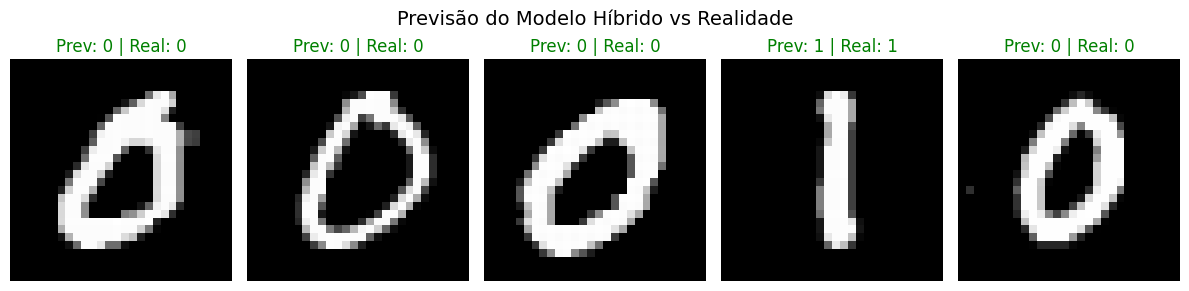

In [ ]:
dados_vis, alvos_vis = next(iter(test_loader))

with torch.no_grad():
    saida_vis = model(dados_vis)
    previsoes_vis = saida_vis.argmax(dim=1)

# Configura a figura do Matplotlib
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
fig.suptitle("Previsão do Modelo Híbrido vs Realidade", fontsize=14)

for i in range(5):
    # Retorna o tensor achatado para o formato 2D da imagem original (28x28)
    imagem = dados_vis[i].view(28, 28).numpy()

    previsao = previsoes_vis[i].item()
    real = alvos_vis[i].item()

    axes[i].imshow(imagem, cmap="gray")

    # Texto verde para acertos, vermelho para erros
    cor = "green" if previsao == real else "red"
    axes[i].set_title(f"Prev: {previsao} | Real: {real}", color=cor)
    axes[i].axis("off")

plt.tight_layout()
plt.show()